### Perform clustering via sectors

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

groups = pd.read_csv("../out/groups/assignments_K00370_v2.tsv", header = None, sep = '\t').values #group membership, alphabetical ordering of ORFs
group_ordering = []
for i in range(len(groups)):
    group_ordering.append(groups[i][0][0:-2]) #group membership, only the ORF name
    
# print(groups)
group_membership_original = np.zeros(57)
for i in range(57):
    group_membership_original[i] = int(groups[i][0][-1]) #group membership, number only

# print(group_membership_original)
    

abundances = pd.read_csv("../out/K00370abundances/complete_abundances_nrm.tsv", header = None, sep = '\t').values #abundances, alphabetical ordering

# with open('../data/msa_sectors/seqids.txt', 'r') as file:
#     ordering = [line.strip() for line in file] #IDs, MSA ordering
    
orf_ids = pd.read_csv('../out/aaseqs/K00370/long_complete_orf_ids.txt', header = None).values

orf_ids = [orf[0] for orf in orf_ids]
print(orf_ids)


sector_0_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_0_msapos.npy") #sectors, MSA ordering
sector_1_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_1_msapos.npy") 
sector_2_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_2_msapos.npy") 
sector_3_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_3_msapos.npy") 
sector_4_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_4_msapos.npy") 
sector_5_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_5_msapos.npy") 
sector_6_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_6_msapos.npy") 
sector_7_ind = np.load("../data/isolate_seqs/isolates_sca_results/sector_7_msapos.npy") 

retained_ids = np.load("../data/isolate_seqs/isolates_sca_results/retained_sequence_ids.npy").tolist()

orf_indices = [retained_ids.index(id) for id in orf_ids]

for index in orf_indices:
    print(retained_ids[index])
    
msa = np.load('../data/isolate_seqs/isolates_sca_results/msa.npy')
msa_variants = msa[orf_indices]

sector_0 = msa_variants[:, sector_0_ind]
sector_1 = msa_variants[:, sector_1_ind]
sector_2 = msa_variants[:, sector_2_ind]
sector_3 = msa_variants[:, sector_3_ind]
sector_4 = msa_variants[:, sector_4_ind]
sector_5 = msa_variants[:, sector_5_ind]
sector_6 = msa_variants[:, sector_6_ind]
sector_7 = msa_variants[:, sector_7_ind]

index_map = {element: index for index, element in enumerate(group_ordering)}


# indices = [index_map[element] for element in ordering] #create an index map between the two orderings

# # #check: these two things should be the same
# print(ordering[10]) #10th in MSA ordering
# print(group_ordering[indices[10]]) #should be 10th in MSA ordering also

group_membership = group_membership_original #same ordering here
print(group_membership)

# group_membership = np.zeros(57)
# for i in range(57):
#     group_membership[i] = int(groups[indices[i]][0][-1]) #group membership number, MSA Ordering
    
    
# abundances = abundances[indices]

['Soil11.scaffold_431547323_c1_2', 'Soil11.scaffold_587233302_c1_1', 'Soil11.scaffold_65427810_c1_20', 'Soil11.scaffold_211583530_c1_6', 'Soil12.scaffold_266712765_c1_2', 'Soil14.scaffold_576820813_c1_40', 'Soil14.scaffold_280216268_c1_12', 'Soil14.scaffold_465502786_c1_2', 'Soil14.scaffold_596019752_c1_119', 'Soil15.scaffold_116822102_c1_19', 'Soil15.scaffold_175810641_c1_3', 'Soil15.scaffold_16321085_c1_6', 'Soil15.scaffold_1255266399_c1_142', 'Soil16.scaffold_436666653_c1_2', 'Soil16.scaffold_804923086_c1_3', 'Soil16.scaffold_313969256_c1_10', 'Soil16.scaffold_1312607544_c1_3', 'Soil17.scaffold_1045002370_c1_23', 'Soil17.scaffold_918557319_c1_2', 'Soil17.scaffold_1202428475_c1_2', 'Soil17.scaffold_274056314_c1_61', 'Soil17.scaffold_332687915_c1_2', 'Soil3.scaffold_414071996_c1_8', 'Soil3.scaffold_333288240_c1_8', 'Soil3.scaffold_530221301_c1_2', 'Soil3.scaffold_408070428_c1_2', 'Soil3.scaffold_285743490_c1_2', 'Soil5.scaffold_133269568_c1_66', 'Soil5.scaffold_215117222_c1_59', 'Soil

In [2]:
from collections import Counter
def compare(arr1, arr2):
    count1 = Counter(arr1)
    count2 = Counter(arr2)
    shared = sum(min(count1[element], count2[element]) 
                for element in set(arr1) | set(arr2) 
                if element != 21)
    return shared #compare two already aligned arrays, don't include shared gaps

print(compare([1,2,1,21,5,21,18], [1,4,1,21,8,21,18]))

3


In [3]:
print(sector_3[10])
print(sector_3[20])
print(compare(sector_3[10], sector_3[20]))

[18 18  6  1  1 15  1 18 19 19 19 13 11 19 14 14 12 12 14  2 16 12  3 14
 14 17  3  2 16  5  5  5  5 18 14  8 12 14  5 14 15 17 17 15 15  9  8  0
 14 19 19  9  5 16 18  5 14  5 17 15 19  2 14  4  5 12 16  7 16  5 12  0
  0  0  2  3 15  7 19 17  9  8 14  5 15 13 11  3  7 15]
[18 18  6  1  1 18  1 18 19 19 19 13 11 19 14 14 12 12 14  2 16 12  3 14
 14 17  3  2 16  5  5  5  5 18 14  8 12 14  5 14 15 17 17 15 15  9  8  0
 14 19  6 12  5  0 18  5 14  5 17 15 19  2 14  4  5 12 15  7 16  5 12  0
  3  0 11  3 15 13  4 16  9  8 14  5  3  8 16  3  7 15]
83


In [4]:
#compute alignment scores

sector3_algn = np.zeros((57, 57))

for i in range(57):
    for j in range(57):
        sector3_algn[i, j] = compare(sector_3[i], sector_3[j])
        
# plt.imshow(sector3_algn, origin = 'lower', cmap = 'Purples')
# plt.colorbar()

In [5]:
#compute alignment scores

sector5_algn = np.zeros((57, 57))

for i in range(57):
    for j in range(57):
        sector5_algn[i, j] = compare(sector_5[i], sector_5[j])
        
# plt.imshow(sector5_algn, origin = 'lower', cmap = 'Oranges')
# plt.colorbar()

Perform Hierarchical Clustering on Sector 3

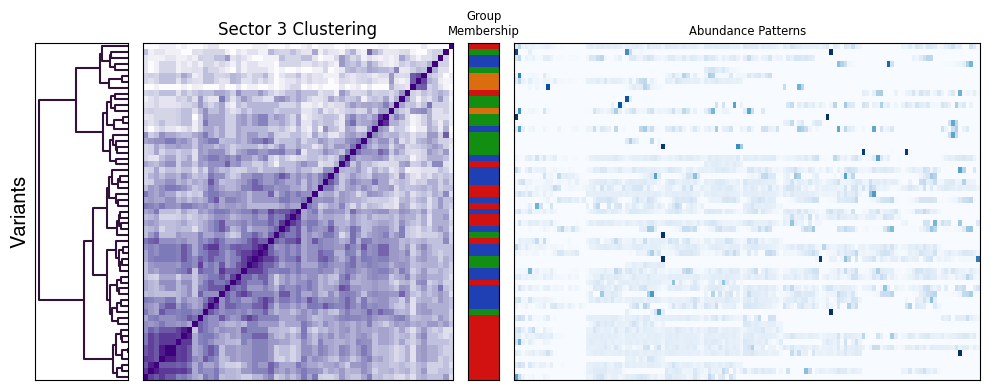

In [6]:
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster, optimal_leaf_ordering
from scipy.cluster import hierarchy
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy.spatial.distance import pdist
from matplotlib.colors import to_hex
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from matplotlib.colors import ListedColormap


my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector3_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Purples',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 3 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

Clustering of sector 5

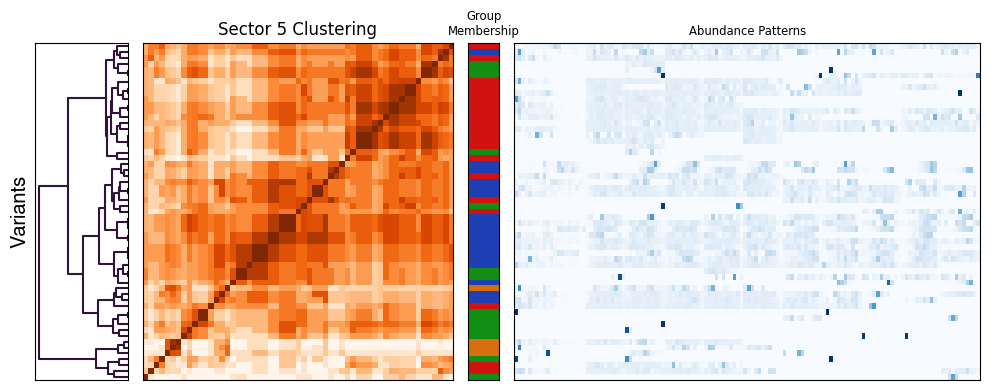

In [7]:


alignment_matrix = scaler.fit_transform(sector5_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Oranges',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])
ax2.set_title('Sector 5 Clustering')

#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize = 'small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

### Look at residue level entropy within and between clusters. 

In [8]:
# #start with sector 3

# print(sector_3.shape)
# print(sector_5.shape)

# sector_0_ind = np.load('../data/msa_sectors/groups/group_0_msapos.npy')
# sector_1_ind = np.load('../data/msa_sectors/groups/group_1_msapos.npy')
# sector_2_ind = np.load('../data/msa_sectors/groups/group_2_msapos.npy')
# sector_3_ind = np.load('../data/msa_sectors/groups/group_3_msapos.npy')
# sector_4_ind = np.load('../data/msa_sectors/groups/group_4_msapos.npy')
# sector_5_ind = np.load('../data/msa_sectors/groups/group_5_msapos.npy')
# sector_6_ind = np.load('../data/msa_sectors/groups/group_6_msapos.npy')
# sector_7_ind = np.load('../data/msa_sectors/groups/group_7_msapos.npy')
# MSA = np.load('../data/msa_sectors/msa.npy')
# positions_57 = np.load('../data/msa_sectors/soilseqs57_positions_in_msa.npy')
# print('positoins_57: ', positions_57)
# MSA_57 = MSA[positions_57]
# print(MSA_57.shape)
# plt.imshow(MSA_57, cmap = 'RdBu')


Text(0.5, 0, 'Position in MSA')

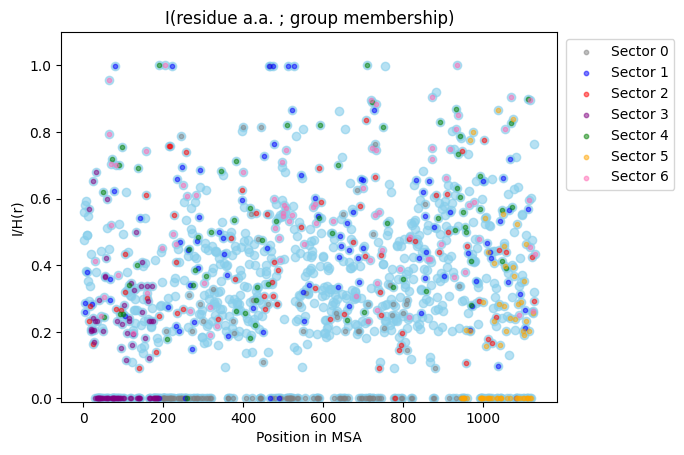

In [9]:
import math
from collections import Counter

# def entropy(values):
#     total = len(values)
#     counts = Counter(values)
#     probs = [count / total for count in counts.values()]
#     return -sum(p * math.log2(p) for p in probs if p > 0)

def entropy(values):
    # Filter out gaps (value 21)
    filtered = [v for v in values if v != 21]
    total = len(filtered)
    if total == 0:
        return 0.0  # No valid values, entropy is zero
    counts = Counter(filtered)
    probs = [count / total for count in counts.values()]
    return -sum(p * math.log2(p) for p in probs if p > 0)

def mutual_information(x, y):
    joint = list(zip(x, y))
    return entropy(x) + entropy(y) - entropy(joint)

def column_entropy(matrix):
    entropies = []
    for col in matrix.T:
        entropies.append(entropy(col))
    return entropies 

def column_mi(matrix, y):
    mi = []
    for col in matrix.T:
        mi.append(mutual_information(col, y))
    return mi

MI_array = [a / (b + 0.0001) for a, b in zip(column_mi(msa_variants, group_membership),column_entropy(msa_variants))]

x = np.linspace(1, len(MI_array), len(MI_array))

plt.scatter(x, MI_array, color = 'skyblue', alpha = 0.6)

#make sector 0 gray
highlight_x = [x[i] for i in sector_0_ind]
highlight_y = [MI_array[i] for i in sector_0_ind]
plt.scatter(highlight_x, highlight_y, color='gray', label='Sector 0', s = 10, alpha = 0.5)
#make sector 1 blue 
highlight_x = [x[i] for i in sector_1_ind]
highlight_y = [MI_array[i] for i in sector_1_ind]
plt.scatter(highlight_x, highlight_y, color='blue', label='Sector 1', s = 10, alpha = 0.5)
#make sector 2 red 
highlight_x = [x[i] for i in sector_2_ind]
highlight_y = [MI_array[i] for i in sector_2_ind]
plt.scatter(highlight_x, highlight_y, color='red', label='Sector 2', s = 10, alpha = 0.5)
#make sector 3 purple 
highlight_x = [x[i] for i in sector_3_ind]
highlight_y = [MI_array[i] for i in sector_3_ind]
plt.scatter(highlight_x, highlight_y, color='purple', label='Sector 3', s = 10, alpha = 0.5)
#make sector 4 green 
highlight_x = [x[i] for i in sector_4_ind]
highlight_y = [MI_array[i] for i in sector_4_ind]
plt.scatter(highlight_x, highlight_y, color='green', label='Sector 4', s = 10, alpha = 0.5)
#make sector 5 orange
highlight_x = [x[i] for i in sector_5_ind]
highlight_y = [MI_array[i] for i in sector_5_ind]
plt.scatter(highlight_x, highlight_y, color='orange', label='Sector 5', s = 10, alpha = 0.5)
#make sector 6 pink
highlight_x = [x[i] for i in sector_6_ind]
highlight_y = [MI_array[i] for i in sector_6_ind]
plt.scatter(highlight_x, highlight_y, color='hotpink', label='Sector 6', s = 10, alpha = 0.5)


plt.ylim(-0.01,1.1)
plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title('I(residue a.a. ; group membership)')
plt.ylabel('I/H(r)')
plt.xlabel('Position in MSA')

In [10]:
group_1 = np.zeros(57)
group_2 = np.zeros(57)
group_3 = np.zeros(57)
group_4 = np.zeros(57)
for i in range(57):
    if group_membership[i] == 1:
        group_1[i] = 1
    elif group_membership[i] == 2:
        group_2[i] = 1
    elif group_membership[i] == 3:
        group_3[i] = 1
    elif group_membership[i] == 4:
        group_4[i] = 1

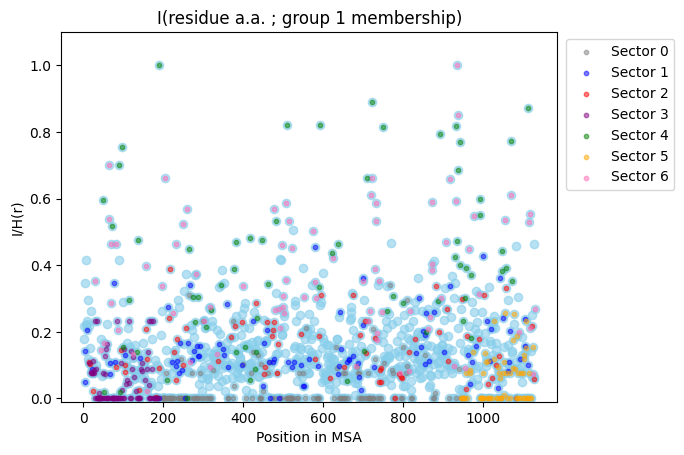

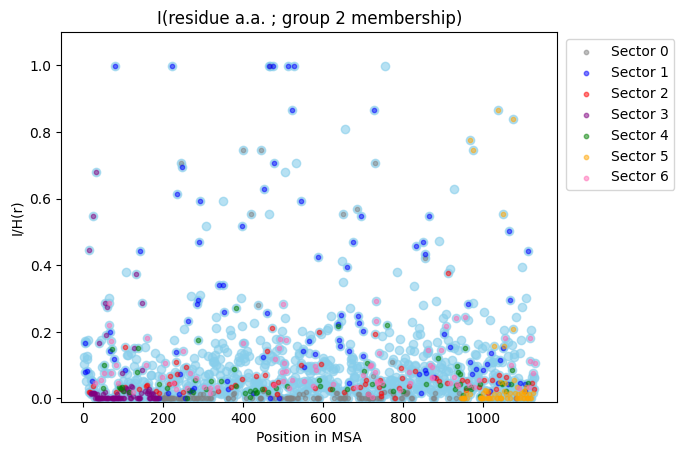

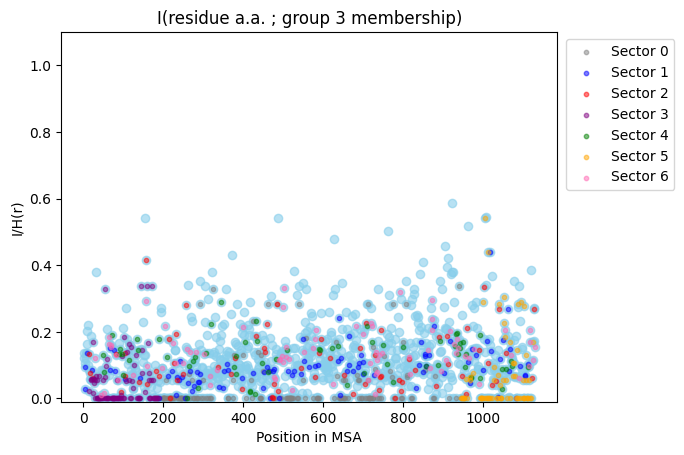

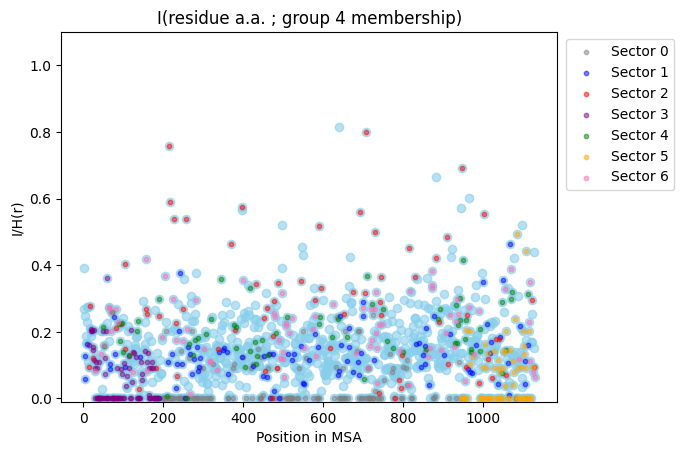

In [15]:
#Info with group 1


MI_1 = [a / (b + 0.0001) for a, b in zip(column_mi(msa_variants, group_1),column_entropy(msa_variants))]

x = np.linspace(1, len(MI_array), len(MI_array))

plt.scatter(x, MI_1, color = 'skyblue', alpha = 0.6)

#make sector 0 gray
highlight_x = [x[i] for i in sector_0_ind]
highlight_y = [MI_1[i] for i in sector_0_ind]
plt.scatter(highlight_x, highlight_y, color='gray', label='Sector 0', s = 10, alpha = 0.5)
#make sector 1 blue 
highlight_x = [x[i] for i in sector_1_ind]
highlight_y = [MI_1[i] for i in sector_1_ind]
plt.scatter(highlight_x, highlight_y, color='blue', label='Sector 1', s = 10, alpha = 0.5)
#make sector 2 red 
highlight_x = [x[i] for i in sector_2_ind]
highlight_y = [MI_1[i] for i in sector_2_ind]
plt.scatter(highlight_x, highlight_y, color='red', label='Sector 2', s = 10, alpha = 0.5)
#make sector 3 purple 
highlight_x = [x[i] for i in sector_3_ind]
highlight_y = [MI_1[i] for i in sector_3_ind]
plt.scatter(highlight_x, highlight_y, color='purple', label='Sector 3', s = 10, alpha = 0.5)
#make sector 4 green 
highlight_x = [x[i] for i in sector_4_ind]
highlight_y = [MI_1[i] for i in sector_4_ind]
plt.scatter(highlight_x, highlight_y, color='green', label='Sector 4', s = 10, alpha = 0.5)
#make sector 5 orange
highlight_x = [x[i] for i in sector_5_ind]
highlight_y = [MI_1[i] for i in sector_5_ind]
plt.scatter(highlight_x, highlight_y, color='orange', label='Sector 5', s = 10, alpha = 0.5)
#make sector 6 pink
highlight_x = [x[i] for i in sector_6_ind]
highlight_y = [MI_1[i] for i in sector_6_ind]
plt.scatter(highlight_x, highlight_y, color='hotpink', label='Sector 6', s = 10, alpha = 0.5)



plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title('I(residue a.a. ; group 1 membership)')
plt.ylabel('I/H(r)')
plt.xlabel('Position in MSA')
plt.ylim(-0.01,1.1)
plt.show()

#Info with group 1


MI_2 = [a / (b + 0.0001) for a, b in zip(column_mi(msa_variants, group_2),column_entropy(msa_variants))]

x = np.linspace(1, len(MI_array), len(MI_array))

plt.scatter(x, MI_2, color = 'skyblue', alpha = 0.6)

#make sector 0 gray
highlight_x = [x[i] for i in sector_0_ind]
highlight_y = [MI_2[i] for i in sector_0_ind]
plt.scatter(highlight_x, highlight_y, color='gray', label='Sector 0', s = 10, alpha = 0.5)
#make sector 1 blue 
highlight_x = [x[i] for i in sector_1_ind]
highlight_y = [MI_2[i] for i in sector_1_ind]
plt.scatter(highlight_x, highlight_y, color='blue', label='Sector 1', s = 10, alpha = 0.5)
#make sector 2 red 
highlight_x = [x[i] for i in sector_2_ind]
highlight_y = [MI_2[i] for i in sector_2_ind]
plt.scatter(highlight_x, highlight_y, color='red', label='Sector 2', s = 10, alpha = 0.5)
#make sector 3 purple 
highlight_x = [x[i] for i in sector_3_ind]
highlight_y = [MI_2[i] for i in sector_3_ind]
plt.scatter(highlight_x, highlight_y, color='purple', label='Sector 3', s = 10, alpha = 0.5)
#make sector 4 green 
highlight_x = [x[i] for i in sector_4_ind]
highlight_y = [MI_2[i] for i in sector_4_ind]
plt.scatter(highlight_x, highlight_y, color='green', label='Sector 4', s = 10, alpha = 0.5)
#make sector 5 orange
highlight_x = [x[i] for i in sector_5_ind]
highlight_y = [MI_2[i] for i in sector_5_ind]
plt.scatter(highlight_x, highlight_y, color='orange', label='Sector 5', s = 10, alpha = 0.5)
#make sector 6 pink
highlight_x = [x[i] for i in sector_6_ind]
highlight_y = [MI_2[i] for i in sector_6_ind]
plt.scatter(highlight_x, highlight_y, color='hotpink', label='Sector 6', s = 10, alpha = 0.5)



plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title('I(residue a.a. ; group 2 membership)')
plt.ylabel('I/H(r)')
plt.xlabel('Position in MSA')
plt.ylim(-0.01,1.1)
plt.show()

#Info with group 3


MI_3 = [a / (b + 0.0001) for a, b in zip(column_mi(msa_variants, group_3),column_entropy(msa_variants))]

x = np.linspace(1, len(MI_array), len(MI_array))

plt.scatter(x, MI_3, color = 'skyblue', alpha = 0.6)

#make sector 0 gray
highlight_x = [x[i] for i in sector_0_ind]
highlight_y = [MI_3[i] for i in sector_0_ind]
plt.scatter(highlight_x, highlight_y, color='gray', label='Sector 0', s = 10, alpha = 0.5)
#make sector 1 blue 
highlight_x = [x[i] for i in sector_1_ind]
highlight_y = [MI_3[i] for i in sector_1_ind]
plt.scatter(highlight_x, highlight_y, color='blue', label='Sector 1', s = 10, alpha = 0.5)
#make sector 2 red 
highlight_x = [x[i] for i in sector_2_ind]
highlight_y = [MI_3[i] for i in sector_2_ind]
plt.scatter(highlight_x, highlight_y, color='red', label='Sector 2', s = 10, alpha = 0.5)
#make sector 3 purple 
highlight_x = [x[i] for i in sector_3_ind]
highlight_y = [MI_3[i] for i in sector_3_ind]
plt.scatter(highlight_x, highlight_y, color='purple', label='Sector 3', s = 10, alpha = 0.5)
#make sector 4 green 
highlight_x = [x[i] for i in sector_4_ind]
highlight_y = [MI_3[i] for i in sector_4_ind]
plt.scatter(highlight_x, highlight_y, color='green', label='Sector 4', s = 10, alpha = 0.5)
#make sector 5 orange
highlight_x = [x[i] for i in sector_5_ind]
highlight_y = [MI_3[i] for i in sector_5_ind]
plt.scatter(highlight_x, highlight_y, color='orange', label='Sector 5', s = 10, alpha = 0.5)
#make sector 6 pink
highlight_x = [x[i] for i in sector_6_ind]
highlight_y = [MI_3[i] for i in sector_6_ind]
plt.scatter(highlight_x, highlight_y, color='hotpink', label='Sector 6', s = 10, alpha = 0.5)



plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title('I(residue a.a. ; group 3 membership)')
plt.ylabel('I/H(r)')
plt.xlabel('Position in MSA')
plt.ylim(-0.01,1.1)
plt.show()

#Info with group 4


MI_4 = [a / (b + 0.0001) for a, b in zip(column_mi(msa_variants, group_4),column_entropy(msa_variants))]

x = np.linspace(1, len(MI_array), len(MI_array))

plt.scatter(x, MI_4, color = 'skyblue', alpha = 0.6)

#make sector 0 gray
highlight_x = [x[i] for i in sector_0_ind]
highlight_y = [MI_4[i] for i in sector_0_ind]
plt.scatter(highlight_x, highlight_y, color='gray', label='Sector 0', s = 10, alpha = 0.5)
#make sector 1 blue 
highlight_x = [x[i] for i in sector_1_ind]
highlight_y = [MI_4[i] for i in sector_1_ind]
plt.scatter(highlight_x, highlight_y, color='blue', label='Sector 1', s = 10, alpha = 0.5)
#make sector 2 red 
highlight_x = [x[i] for i in sector_2_ind]
highlight_y = [MI_4[i] for i in sector_2_ind]
plt.scatter(highlight_x, highlight_y, color='red', label='Sector 2', s = 10, alpha = 0.5)
#make sector 3 purple 
highlight_x = [x[i] for i in sector_3_ind]
highlight_y = [MI_4[i] for i in sector_3_ind]
plt.scatter(highlight_x, highlight_y, color='purple', label='Sector 3', s = 10, alpha = 0.5)
#make sector 4 green 
highlight_x = [x[i] for i in sector_4_ind]
highlight_y = [MI_4[i] for i in sector_4_ind]
plt.scatter(highlight_x, highlight_y, color='green', label='Sector 4', s = 10, alpha = 0.5)
#make sector 5 orange
highlight_x = [x[i] for i in sector_5_ind]
highlight_y = [MI_4[i] for i in sector_5_ind]
plt.scatter(highlight_x, highlight_y, color='orange', label='Sector 5', s = 10, alpha = 0.5)
#make sector 6 pink
highlight_x = [x[i] for i in sector_6_ind]
highlight_y = [MI_4[i] for i in sector_6_ind]
plt.scatter(highlight_x, highlight_y, color='hotpink', label='Sector 6', s = 10, alpha = 0.5)



plt.legend(loc="upper right", bbox_to_anchor=(1.25, 1))
plt.title('I(residue a.a. ; group 4 membership)')
plt.ylabel('I/H(r)')
plt.xlabel('Position in MSA')
plt.ylim(-0.01,1.1)
plt.show()

### Where does the block structure emerge?

Try again with the full MSA. And then with the MSA minus sector indices. 

Perhaps also try highly and variable residues, independently.

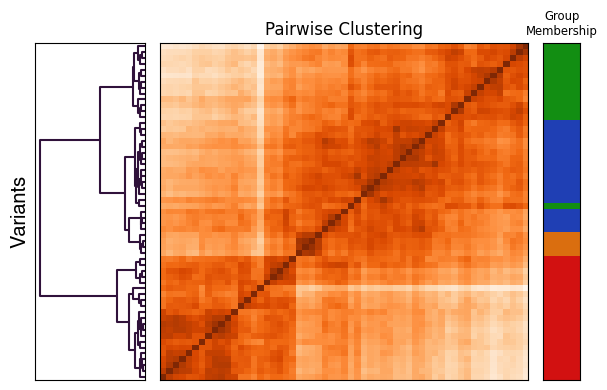

In [ ]:
##first full MSA again

#compute alignment scores

pairwise = np.zeros((57, 57))

for i in range(57):
    for j in range(57):
        pairwise[i, j] = compare(msa_variants[i], msa_variants[j])
        



#alignment_matrix = scaler.fit_transform(pairwise)
alignment_matrix = pairwise

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Oranges',
                interpolation='nearest', origin='lower')
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])
ax2.set_title('Pairwise Clustering')

#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize = 'small')


plt.tight_layout()

    
plt.show()
    


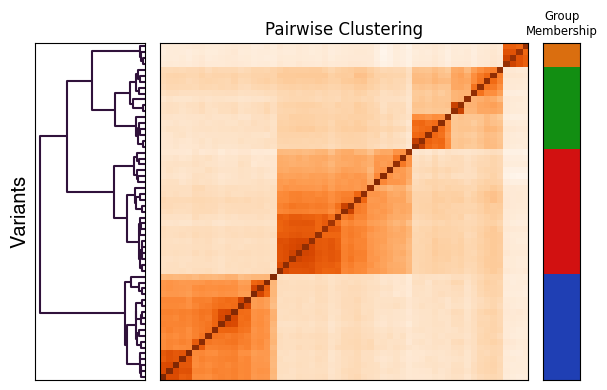

In [ ]:
pairwise_data = np.load(f'../out/aaseqs/K00370/long_complete_pwalignment_scores.npy')

alignment_matrix = pairwise_data

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Oranges',
                interpolation='nearest', origin='lower')
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])
ax2.set_title('Pairwise Clustering')

#plot group membership
groups_rearranged = group_membership_original[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize = 'small')


plt.tight_layout()

    
plt.show()

In [ ]:
print(groups_rearranged)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 4. 4. 4. 4. 4. 4.
 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 4. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 2. 2. 2. 2.]


### Let's do hierarchical clustering on the other sectors



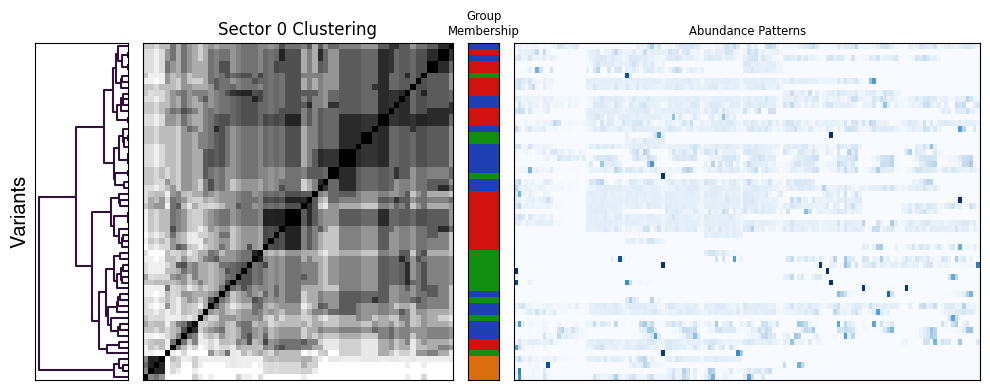

In [ ]:

sector0_algn = np.zeros((57, 57))
sector_0 = msa_variants[:,sector_0_ind]

for i in range(57):
    for j in range(57):
        sector0_algn[i, j] = compare(sector_0[i], sector_0[j])

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector0_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Greys',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 0 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

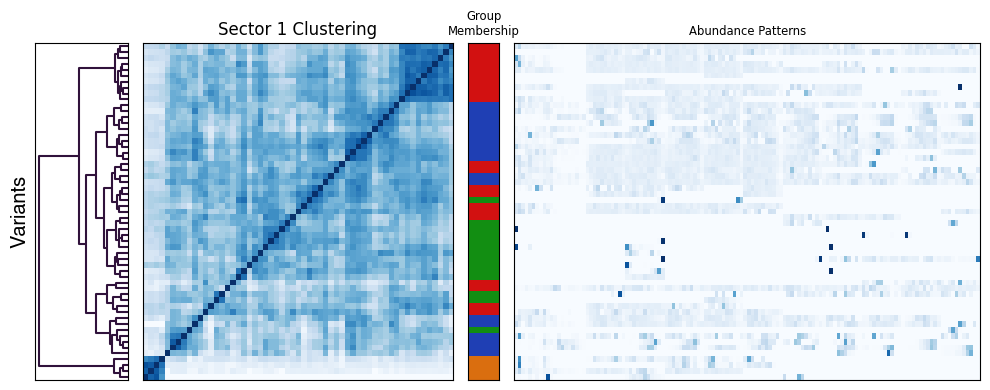

In [ ]:

sector1_algn = np.zeros((57, 57))
sector_1 = msa_variants[:,sector_1_ind]

for i in range(57):
    for j in range(57):
        sector1_algn[i, j] = compare(sector_1[i], sector_1[j])

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector1_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Blues',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 1 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

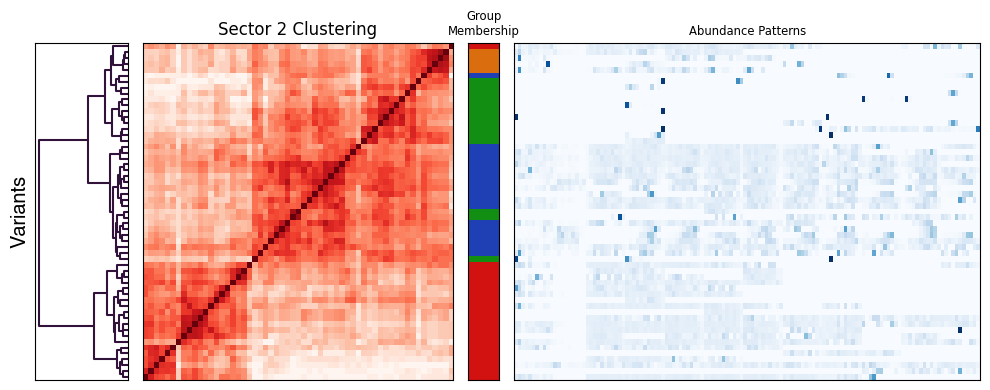

In [ ]:

sector2_algn = np.zeros((57, 57))
sector_2 = msa_variants[:,sector_2_ind]

for i in range(57):
    for j in range(57):
        sector2_algn[i, j] = compare(sector_2[i], sector_2[j])

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector2_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Reds',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 2 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

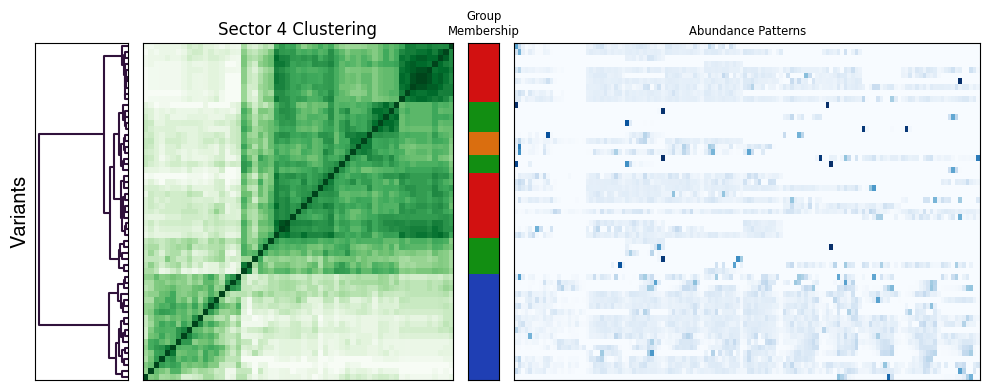

In [ ]:

sector4_algn = np.zeros((57, 57))
sector_4 = msa_variants[:,sector_4_ind]

for i in range(57):
    for j in range(57):
        sector4_algn[i, j] = compare(sector_4[i], sector_4[j])

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector4_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='Greens',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 4 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

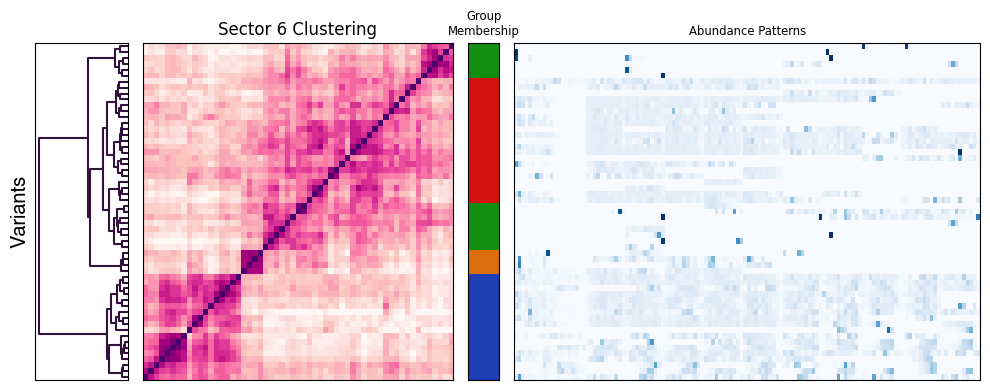

In [ ]:

sector6_algn = np.zeros((57, 57))
sector_6 = msa_variants[:,sector_6_ind]

for i in range(57):
    for j in range(57):
        sector6_algn[i, j] = compare(sector_6[i], sector_6[j])

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

scaler = MinMaxScaler()

alignment_matrix = scaler.fit_transform(sector6_algn)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(10, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1, 1.5]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

im = ax2.imshow(rearranged_data, aspect='auto', cmap='RdPu',
                interpolation='nearest', origin='lower', vmin = 0, vmax = 1)
#plt.colorbar(im, ax=ax2)


boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Sector 6 Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

#plot abundance patterns
abundances_rearranged = abundances[leaf_indices]
im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

ax4.set_xticks([])
ax4.set_yticks([])
ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

### Now do clustering on conserved and poorly conserved indices, seperately. 

[0.90752872 0.75888649 1.74437748 ... 1.49832663 0.77175463 1.80445329]


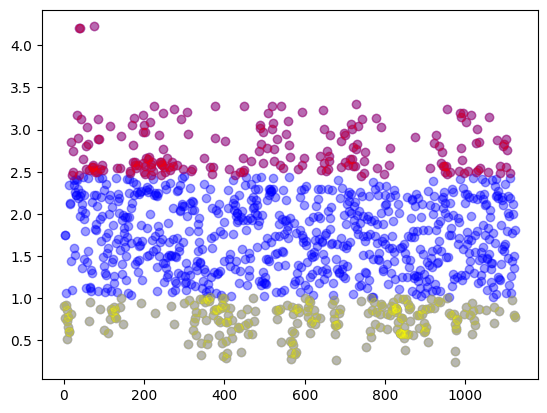

In [ ]:
conservation = np.load('../data/msa_sectors/conservation.npy')
print(conservation)
x = np.linspace(1,len(conservation), len(conservation))
plt.scatter(x, conservation, color = 'Blue', alpha = 0.4)
consv_ind = np.where(conservation > np.mean(conservation) + np.std(conservation))
varia_ind = np.where(conservation < np.mean(conservation) - np.std(conservation))
plt.scatter(x[consv_ind], conservation[consv_ind], color = 'Red', alpha = 0.3)
plt.scatter(x[varia_ind], conservation[varia_ind], color = 'Yellow', alpha = 0.3)
plt.show()
# print(consv_ind[0])
varia_ind = varia_ind[0]
consv_ind = consv_ind[0]
# plt.hist(consv_ind, bins = 20)

mean alignment:  0.9074436176440414


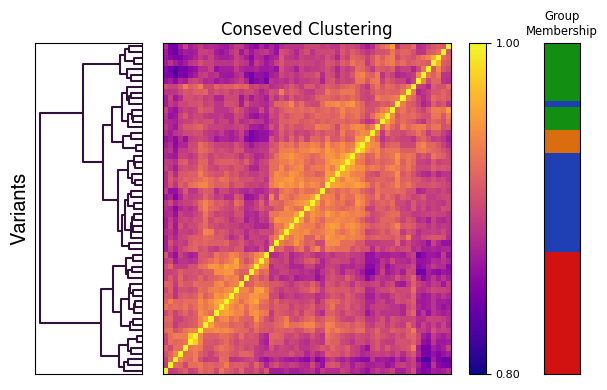

In [ ]:

consv_algn = np.zeros((57, 57))
MSA_consv = msa_variants[:,consv_ind]

for i in range(57):
    for j in range(57):
        consv_algn[i, j] = compare(MSA_consv[i], MSA_consv[j])
        
print('mean alignment: ', np.mean(consv_algn)/len(consv_ind))

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

# scaler = MinMaxScaler()
# alignment_matrix = scaler.fit_transform(consv_algn)

alignment_matrix = consv_algn/len(consv_ind)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

vmin = 0.8
im = ax2.imshow(rearranged_data, aspect='auto', cmap='plasma',
                interpolation='nearest', origin='lower', vmin = vmin, vmax = 1)

cbar = fig.colorbar(im, ax=ax2)
# cbar.set_label('% Alignment')  # Optional: label for the colorbar
ticks = np.linspace(vmin, 1, 2)  
cbar.set_ticks(ticks)


tick_labels = [f"{tick:.2f}" for tick in ticks]
cbar.set_ticklabels(tick_labels)


cbar.ax.tick_params(labelsize=8)

boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Conseved Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

# #plot abundance patterns
# abundances_rearranged = abundances[leaf_indices]
# im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

# ax4.set_xticks([])
# ax4.set_yticks([])
# ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    

mean alignment:  0.8618036318867344


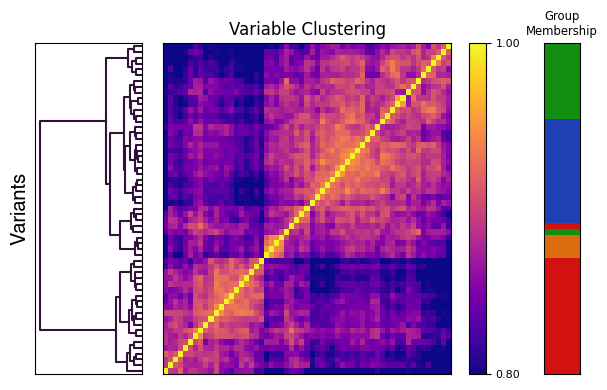

In [ ]:

varia_algn = np.zeros((57, 57))
MSA_varia = msa_variants[:,varia_ind]

for i in range(57):
    for j in range(57):
        varia_algn[i, j] = compare(MSA_varia[i], MSA_varia[j])
        
print('mean alignment: ', np.mean(varia_algn)/len(varia_ind))

my_cmap = ListedColormap(["#1f3fb4", "#da6e0f", "#128E12", "#d21111"])

# scaler = MinMaxScaler()
# alignment_matrix = scaler.fit_transform(consv_algn)

alignment_matrix = varia_algn/len(varia_ind)

Z = linkage(alignment_matrix, method='ward', metric='euclidean')
Z_optimal = optimal_leaf_ordering(Z, pdist(alignment_matrix, metric='euclidean'))

n_clusters = 1
clusters = fcluster(Z_optimal, t=n_clusters, criterion='maxclust')

dendro = dendrogram(Z_optimal, no_plot=True)
leaf_indices = dendro['leaves']

idx_to_cluster = {i: clusters[i] for i in range(len(clusters))}


next_node = len(clusters)
node_to_cluster = {}

for i, (left, right, _, _) in enumerate(Z_optimal):
    left, right = int(left), int(right)
    left_cluster = idx_to_cluster.get(left, node_to_cluster.get(left, -1))
    right_cluster = idx_to_cluster.get(right, node_to_cluster.get(right, -1))
    if left_cluster == right_cluster and left_cluster != -1:
        node_to_cluster[next_node] = left_cluster
    next_node += 1
    
#cluster_colors = ['#1f77b4', "#9729E0", "#610a70", "#210bcb"]
cmap = plt.cm.turbo # Or any other colormap (e.g., 'viridis', 'plasma')
cluster_colors = [to_hex(cmap(i)) for i in np.linspace(0, 1, n_clusters)]

def color_func(link_idx):
    cluster_id = node_to_cluster.get(link_idx, -1)
    if cluster_id != -1 and cluster_id <= len(cluster_colors):
        return cluster_colors[cluster_id - 1]
    return "#000000"  # default color for unclustered links


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(6, 4), gridspec_kw={'width_ratios': [0.3, 1, 0.1]})

dendrogram(Z_optimal,
           orientation='left',
           ax=ax1,
           color_threshold=max(Z_optimal[-n_clusters+1, 2], 0.1),
           link_color_func=color_func,
           above_threshold_color='k')

ax1.set_title('')
ax1.set_xlabel('')
ax1.set_ylabel('Variants', fontname='Helvetica', fontsize = 'x-large')
ax1.set_xticks([])
ax1.set_yticks([])
ax1.tick_params(left=False, bottom=False)

data = np.array(alignment_matrix)

rearranged_data = data[leaf_indices]
rearranged_data = rearranged_data[:, leaf_indices]

vmin = 0.8
im = ax2.imshow(rearranged_data, aspect='auto', cmap='plasma',
                interpolation='nearest', origin='lower', vmin = vmin, vmax = 1)

cbar = fig.colorbar(im, ax=ax2)
# cbar.set_label('% Alignment')  # Optional: label for the colorbar
ticks = np.linspace(vmin, 1, 2)  
cbar.set_ticks(ticks)


tick_labels = [f"{tick:.2f}" for tick in ticks]
cbar.set_ticklabels(tick_labels)


cbar.ax.tick_params(labelsize=8)

boundaries = np.where(np.diff(clusters[leaf_indices]))[0]
# for b in boundaries:
#     ax2.axhline(b + 0.5, color='black', linestyle='--')
    
# ax2.axvline(19.5, color='black', linestyle='--')
# ax2.axvline(129.5, color='black', linestyle='--')
# ax2.axvline(186.5, color='black', linestyle='--')
ax2.set_xticks([])

ax2.set_yticks([])

ax2.set_title('Variable Clustering')


#plot group membership
groups_rearranged = group_membership[leaf_indices]
im = ax3.imshow(groups_rearranged.reshape(-1, 1), aspect='auto', cmap = my_cmap, origin = 'lower')

ax3.set_xticks([])
ax3.set_yticks([])
ax3.set_title('Group\nMembership', fontsize ='small')

# #plot abundance patterns
# abundances_rearranged = abundances[leaf_indices]
# im = ax4.imshow(abundances_rearranged, aspect = 'auto', cmap = 'Blues', origin = 'lower')

# ax4.set_xticks([])
# ax4.set_yticks([])
# ax4.set_title('Abundance Patterns', fontsize ='small')

plt.tight_layout()

    
plt.show()
    